In [1]:
import subprocess, sys

packages = ['groq', 'rank_bm25', 'pandas', 'numpy', 'scikit-learn',
            'matplotlib', 'seaborn', 'tqdm']

for pkg in packages:
    print(f'Installing {pkg}...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

print('\n✅ All packages installed!')

Installing groq...
Installing rank_bm25...
Installing pandas...
Installing numpy...
Installing scikit-learn...
Installing matplotlib...
Installing seaborn...
Installing tqdm...

✅ All packages installed!


In [2]:
import os

cuda_runtime = r"C:\Users\yrghimire\AppData\Local\miniconda3\envs\legal_rag\Lib\site-packages\nvidia\cuda_runtime\bin"
cuda_cublas  = r"C:\Users\yrghimire\AppData\Local\miniconda3\envs\legal_rag\Lib\site-packages\nvidia\cublas\bin"
os.environ["PATH"] = cuda_runtime + ";" + cuda_cublas + ";" + os.environ["PATH"]

print("✅ CUDA PATH set!")

✅ CUDA PATH set!


In [3]:
import re
import ast
import time
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
from rank_bm25 import BM25Okapi
from groq import Groq

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 100)
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

print('✅ All libraries imported!')

✅ All libraries imported!


In [ ]:
import os
groq_api_key = os.getenv("GROQ_API_KEY", "your-key-here")

DATA_PATH = Path(r"C:\Users\yrghimire\Chapter\spring_2026\comp841\code\llm-agentic-legal-information-retrieval")

# ═══════════════════════════════════════════════════════

# Model settings
GROQ_MODEL   = "llama-3.3-70b-versatile"  # best free model on Groq
TEMPERATURE  = 0.1                         # low = more consistent output
MAX_TOKENS   = 1024

# RAG settings
TOP_K_RETRIEVE = 15    # how many law articles to retrieve per query
TOP_K_PREDICT  = 20    # max citations to return per query

# Output
OUTPUT_PATH = Path("./final_model_output")
OUTPUT_PATH.mkdir(exist_ok=True)

# Validate
if GROQ_API_KEY == "groq_api_key":
    print("⚠️  WARNING: Set your GROQ_API_KEY above!")
    print("   Get one free at https://console.groq.com")
else:
    print(f"✅ Groq API key set ({GROQ_API_KEY[:8]}...)")

print(f"✅ Data path   : {DATA_PATH}")
print(f"✅ Groq model  : {GROQ_MODEL}")
print(f"✅ Output path : {OUTPUT_PATH}")

⚠️  WARNING: Set your GROQ_API_KEY above!
   Get one free at https://console.groq.com
✅ Data path   : C:\Users\yrghimire\Chapter\spring_2026\comp841\code\llm-agentic-legal-information-retrieval
✅ Groq model  : llama-3.3-70b-versatile
✅ Output path : final_model_output


In [6]:
# ── Load train.csv ────────────────────────────────────────
# Used to: learn frequent citation patterns
train_path = DATA_PATH / "train.csv"
train_df = pd.read_csv(train_path)
print(f"✅ train.csv  : {len(train_df):,} queries loaded")

# ── Load val.csv ──────────────────────────────────────────
# Used to: evaluate model accuracy (has gold_citations)
val_path = DATA_PATH / "val.csv"
val_df = pd.read_csv(val_path)
print(f"✅ val.csv    : {len(val_df):,} queries loaded")

# ── Load test.csv ─────────────────────────────────────────
# Used to: generate final submission (no gold_citations)
test_path = DATA_PATH / "test.csv"
test_df = pd.read_csv(test_path)
print(f"✅ test.csv   : {len(test_df):,} queries loaded")

# ── Load laws_de.csv ──────────────────────────────────────
# Used to: search for relevant law articles (RAG corpus)
laws_path = DATA_PATH / "laws_de.csv"
laws_df = pd.read_csv(laws_path)
laws_df['text'] = laws_df['text'].fillna('')
laws_df['title'] = laws_df['title'].fillna('')
print(f"✅ laws_de.csv: {len(laws_df):,} law articles loaded")

# ── Show sample data ──────────────────────────────────────
print("\n--- Sample train query ---")
print(f"Query : {train_df['query'].iloc[0][:150]}...")
print(f"Gold  : {train_df['gold_citations'].iloc[0][:150]}")

print("\n--- Sample val query ---")
print(f"Query : {val_df['query'].iloc[0][:150]}...")
print(f"Gold  : {val_df['gold_citations'].iloc[0][:100]}...")

print("\n--- Sample law article ---")
print(f"Citation: {laws_df['citation'].iloc[100]}")
print(f"Text    : {laws_df['text'].iloc[100][:150]}")

✅ train.csv  : 1,139 queries loaded
✅ val.csv    : 10 queries loaded
✅ test.csv   : 40 queries loaded
✅ laws_de.csv: 175,933 law articles loaded

--- Sample train query ---
Query : Die A AG betreibt seit den 1970er-Jahren auf der Parzelle Nr. yyy (Wohn- und Gewerbezone) ein Recyclingunternehmen. Das Unternehmen verarbeitet vorwie...
Gold  : Art. 10a Abs. 1 USG;Art. 2 Abs. 1 UVPV;Art. 10a Abs. 1 UVG

--- Sample val query ---
Query : May a court lawfully order a three‑month extension of pre‑trial detention under Art. 221 Abs. 1 lit. b StPO (risk of collusion) consistent with the pr...
Gold  : Art. 221 Abs. 1 StPO;Art. 140 Abs. 1 StGB;Art. 396 Abs. 1 StPO;Art. 222 StPO;Art. 393 Abs. 1 StPO;Ar...

--- Sample law article ---
Citation: Art. 38 Abs. 3 131.211
Text    : 3 Verfassung und Gesetz bestimmen, welche Behörden Verordnungen erlassen können.


In [7]:
# ── Extract all citations from training data ───────────────
all_train_citations = (
    train_df['gold_citations']
    .str.split(';')
    .explode()
    .str.strip()
    .dropna()
)

citation_freq = Counter(all_train_citations)
top_20_train = [cit for cit, _ in citation_freq.most_common(20)]

print("TOP 20 MOST FREQUENT CITATIONS IN TRAINING DATA")
print("=" * 55)
for i, (cit, cnt) in enumerate(citation_freq.most_common(20), 1):
    bar = '█' * min(cnt, 30)
    print(f"  {i:2}. {cit:<35} {cnt:>4}x  {bar}")

# ── Extract law area frequencies ──────────────────────────
# Which law codes appear most often (ZGB, OR, StGB, etc.)
law_codes = all_train_citations.str.extract(r'(ZGB|OR|StGB|BV|StPO|ZPO|ATSG|IVG|KVG|BGG|SchKG)')[0]
law_freq  = law_codes.dropna().value_counts()

print("\nTOP LAW CODES IN TRAINING DATA")
print("=" * 40)
for code, cnt in law_freq.head(10).items():
    bar = '█' * min(cnt // 10, 30)
    print(f"  {code:<10} {cnt:>5}x  {bar}")

# ── Training stats ────────────────────────────────────────
train_df['n_gold'] = train_df['gold_citations'].str.split(';').str.len()
print(f"\nTraining queries  : {len(train_df):,}")
print(f"Avg citations/query: {train_df['n_gold'].mean():.1f}")
print(f"Total unique citations: {len(citation_freq):,}")

TOP 20 MOST FREQUENT CITATIONS IN TRAINING DATA
   1. Art. 20 Abs. 1 DBG                    20x  ████████████████████
   2. Art. 10 Abs. 2 BV                     16x  ████████████████
   3. Art. 335 ZGB                          15x  ███████████████
   4. Art. 4 Abs. 1 VStG                    14x  ██████████████
   5. Art. 16 Abs. 3 DBG                    14x  ██████████████
   6. Art. 963 Abs. 1 ZGB                   14x  ██████████████
   7. Art. 58 Abs. 1 DBG                    12x  ████████████
   8. Art. 123 StGB                         12x  ████████████
   9. Art. 28 ZGB                           11x  ███████████
  10. Art. 13 Abs. 1 BV                     11x  ███████████
  11. Art. 144 StGB                         11x  ███████████
  12. Art. 41 OR                            11x  ███████████
  13. Art. 20 Abs. 2 OR                     10x  ██████████
  14. Art. 10 Abs. 1 BV                     10x  ██████████
  15. Art. 13 BV                             9x  █████████
  16. Art. 3

In [8]:
def tokenize(text: str) -> list:
    """Split text into words for BM25 search."""
    if not text:
        return []
    return re.findall(r'[a-zA-ZäöüßéàèâÄÖÜ0-9]+\.?[a-zA-Z0-9]*', text.lower())


print("Building BM25 search index from laws_de.csv...")
print(f"Indexing {len(laws_df):,} law articles...")

# Each document = citation + title + text combined
# This gives BM25 more context to match against
law_documents = [
    row['citation'] + ' ' + row['title'] + ' ' + row['text']
    for _, row in laws_df.iterrows()
]

# Tokenize all documents
tokenized_laws = [
    tokenize(doc)
    for doc in tqdm(law_documents, desc='Tokenizing', leave=False)
]

# Build BM25 index
bm25_laws = BM25Okapi(tokenized_laws)

print(f"\n✅ BM25 index built! {len(law_documents):,} articles indexed")

# Quick test
test_q     = "pre-trial detention conditions Switzerland Untersuchungshaft"
test_tok   = tokenize(test_q)
test_scores = bm25_laws.get_scores(test_tok)
top5       = np.argsort(test_scores)[::-1][:5]

print(f"\nTest search: '{test_q}'")
print("Top 5 results:")
for i, idx in enumerate(top5):
    print(f"  {i+1}. [{laws_df.iloc[idx]['citation']}] score={test_scores[idx]:.2f}")
    print(f"     {laws_df.iloc[idx]['text'][:80]}...")

Building BM25 search index from laws_de.csv...
Indexing 175,933 law articles...


Tokenizing:   0%|          | 0/175933 [00:00<?, ?it/s]


✅ BM25 index built! 175,933 articles indexed

Test search: 'pre-trial detention conditions Switzerland Untersuchungshaft'
Top 5 results:
  1. [Art. 226 Abs. 4 StPO] score=13.99
     4 Es kann in seinem Entscheid:a. eine Höchstdauer der Untersuchungshaft festlege...
  2. [Art. 227 Abs. 4 StPO] score=13.31
     4 Es kann die provisorische Fortdauer der Untersuchungshaft bis zu seinem Entsch...
  3. [Art. 226 Abs. 5 StPO] score=13.22
     5 Ordnet es die Untersuchungshaft nicht an, so wird die beschuldigte Person unve...
  4. [Art. 227 Abs. 7 StPO] score=12.86
     7 Die Verlängerung der Untersuchungshaft wird jeweils für längstens 3 Monate, in...
  5. [Art. 44 Abs. 1 MStG] score=12.77
     Das Gericht rechnet die Untersuchungshaft, die der Täter während dieses oder ein...


In [9]:
# Initialize Groq client
client = Groq(api_key=GROQ_API_KEY)
print("✅ Groq client initialized")

# Test connection
try:
    test_response = client.chat.completions.create(
        model=GROQ_MODEL,
        messages=[{"role": "user", "content": "Say OK"}],
        max_tokens=5
    )
    print(f"✅ Groq connection working! Model: {GROQ_MODEL}")
except Exception as e:
    print(f"❌ Groq connection failed: {e}")
    print("   Check your API key at https://console.groq.com")

✅ Groq client initialized
✅ Groq connection working! Model: llama-3.3-70b-versatile


In [10]:
# Swiss law abbreviations for regex
LAW_ABBREVS = (
    "ZGB|OR|StGB|BV|SchKG|ZPO|StPO|BGG|VwVG|IPRG|KG|DSG|MSchG|URG|PatG|"
    "DesG|UWG|FINMAG|BankG|VAG|KAG|GwG|BEHG|FinfraG|FIDLEG|FINIG|"
    "ATSG|KVG|UVG|BVG|ArG|GlG|USG|RPG|SVG|EMRK|"
    "IVG|AHVG|AVIG|DBG|StHG|MWSTG"
)


def extract_citations(text: str) -> list:
    """
    Extract clean citations from LLM output text.
    Handles both Python list format and raw text.
    """
    citations = []

    # Try to parse as Python list first
    try:
        match = re.search(r'\[.*?\]', text, re.DOTALL)
        if match:
            parsed = ast.literal_eval(match.group())
            if isinstance(parsed, list):
                for item in parsed:
                    citations.extend(_regex_find(str(item)))
    except (ValueError, SyntaxError):
        pass

    # Fallback: regex on raw text
    if not citations:
        citations = _regex_find(text)

    # Deduplicate
    seen, unique = set(), []
    for c in citations:
        if c not in seen:
            seen.add(c)
            unique.append(c)
    return unique


def _regex_find(text: str) -> list:
    """Regex patterns to find Swiss legal citations."""
    found = []

    # BGE court decisions: BGE 141 II 345 E. 3.2
    bge = r'BGE\s+(\d+)\s+([IVXivx]+[a-z]?)\s+(\d+)(?:\s+E\.\s*([\d.a-z/]+))?'
    for m in re.finditer(bge, text):
        vol, part, page, consid = m.groups()
        part = part.upper()
        if consid:
            found.append(f"BGE {vol} {part} {page} E. {consid}")
        else:
            found.append(f"BGE {vol} {part} {page}")

    # Law articles: Art. 221 Abs. 1 lit. b StPO
    art = (
        rf'Art\.?\s*(\d+[a-z]?)'
        rf'(?:\s+(Abs\.?\s*\d+))?'
        rf'(?:\s+(lit\.?\s*[a-z]))?'
        rf'(?:\s+(Ziff\.?\s*\d+))?'
        rf'\s+({LAW_ABBREVS})\b'
    )
    for m in re.finditer(art, text, re.IGNORECASE):
        num, abs_p, lit_p, ziff_p, abbrev = m.groups()
        parts = [f"Art. {num}"]
        if abs_p:
            parts.append(re.sub(r'Abs\.?\s*', 'Abs. ', abs_p).strip())
        if lit_p:
            parts.append(re.sub(r'lit\.?\s*', 'lit. ', lit_p).strip())
        if ziff_p:
            parts.append(re.sub(r'Ziff\.?\s*', 'Ziff. ', ziff_p).strip())
        parts.append(abbrev.upper())
        found.append(" ".join(parts))

    return found


# Quick test
test = '["Art. 221 Abs. 1 StPO", "Art. 8 Abs. 1 BV", "BGE 141 IV 289 E. 2.3"]'
print("Extractor test:", extract_citations(test))
print("✅ Citation extractor ready!")

Extractor test: ['Art. 221 Abs. 1 STPO', 'Art. 8 Abs. 1 BV', 'BGE 141 IV 289 E. 2.3']
✅ Citation extractor ready!


In [11]:
def retrieve_laws(query: str, top_k: int = TOP_K_RETRIEVE) -> list:
    """
    Search laws_de.csv using BM25 and return top-k matching articles.
    
    Returns list of dicts: [{citation, text}, ...]
    """
    tokens = tokenize(query)
    scores = bm25_laws.get_scores(tokens)
    top_idx = np.argsort(scores)[::-1][:top_k]

    results = []
    for idx in top_idx:
        if scores[idx] > 0:
            results.append({
                'citation': laws_df.iloc[idx]['citation'],
                'text'    : laws_df.iloc[idx]['text'][:300],  # trim long texts
                'score'   : round(float(scores[idx]), 3),
            })
    return results


def build_prompt(query: str, retrieved_laws: list) -> str:
    """
    Build the prompt sent to the Groq LLM.
    
    Includes:
    - System instructions
    - Real law articles from the corpus (RAG context)
    - The actual query
    """
    # Format retrieved articles as context
    law_context = ""
    for i, law in enumerate(retrieved_laws, 1):
        law_context += f"[{i}] {law['citation']}: {law['text']}\n"

    system_prompt = """You are a Swiss legal citation expert.

TASK: Given a legal query and relevant Swiss law articles, identify the correct legal citations.

CITATION FORMATS (use EXACTLY these formats):
- Law articles: "Art. X ABBREV" or "Art. X Abs. Y ABBREV" or "Art. X Abs. Y lit. z ABBREV"
  Examples: "Art. 1 OR", "Art. 221 Abs. 1 StPO", "Art. 8 Abs. 1 BV"
- Court decisions: "BGE X Y Z" or "BGE X Y Z E. N"
  Examples: "BGE 141 II 345", "BGE 119 II 449 E. 2"

IMPORTANT RULES:
1. Output ONLY a Python list. Nothing else. No explanations.
2. Only cite articles that are truly relevant to the query.
3. Prefer citations from the provided context articles.
4. Do NOT invent or guess citation numbers. Only use real ones.
5. Use EXACT format: "Art. X Abs. Y ABBREV" — capitalisation matters.

OUTPUT FORMAT EXAMPLE:
["Art. 221 Abs. 1 StPO", "Art. 222 StPO", "BGE 141 IV 289 E. 2.3"]"""

    user_message = f"""RELEVANT LAW ARTICLES FROM CORPUS:
{law_context}
QUERY: {query}

Based on the query and the law articles above, provide the relevant citations as a Python list.
Output:"""

    return system_prompt, user_message


def predict_citations(query: str, verbose: bool = False) -> list:
    """
    Full RAG pipeline: retrieve → prompt → generate → extract.
    
    Parameters:
    -----------
    query   : legal question text
    verbose : if True, print retrieved articles and raw LLM output
    
    Returns:
    --------
    List of citation strings
    """
    # Step 1: Retrieve relevant law articles
    retrieved = retrieve_laws(query, top_k=TOP_K_RETRIEVE)

    if verbose:
        print(f"\n  Retrieved {len(retrieved)} law articles:")
        for r in retrieved[:5]:
            print(f"    [{r['citation']}] score={r['score']}")

    # Step 2: Build prompt with real articles
    system_prompt, user_message = build_prompt(query, retrieved)

    # Step 3: Call Groq LLM
    for attempt in range(3):
        try:
            response = client.chat.completions.create(
                model=GROQ_MODEL,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": user_message},
                ],
                max_tokens  = MAX_TOKENS,
                temperature = TEMPERATURE,
                stop        = ["\n\n\n"],
            )
            raw = response.choices[0].message.content.strip()
            break
        except Exception as e:
            print(f"  ⚠️  Attempt {attempt+1}/3 failed: {e}")
            time.sleep(2 ** attempt)
            raw = ""

    if verbose:
        print(f"\n  Raw LLM output: {raw[:200]}")

    # Step 4: Extract clean citations
    citations = extract_citations(raw)
    return citations[:TOP_K_PREDICT]


# ── Test with one val query ────────────────────────────────
print("Testing RAG pipeline on first val query...")
print(f"Query: {val_df['query'].iloc[0][:100]}...\n")

test_cits = predict_citations(val_df['query'].iloc[0], verbose=True)
print(f"\n✅ Generated {len(test_cits)} citations:")
for c in test_cits:
    print(f"   • {c}")

print(f"\nGold citations (first 5):")
for c in val_df['gold_citations'].iloc[0].split(';')[:5]:
    print(f"   • {c.strip()}")

Testing RAG pipeline on first val query...
Query: May a court lawfully order a three‑month extension of pre‑trial detention under Art. 221 Abs. 1 lit....


  Retrieved 15 law articles:
    [Art. 3 Abs. 1 221.434] score=267.327
    [Art. 197e Abs. 2 AVO] score=205.642
    [Art. 6 Abs. 2 ChKV] score=168.231
    [Art. 95 Abs. 2 PSMV] score=138.322
    [Art. 43 Abs. 4 VNF] score=114.577

  Raw LLM output: ["Art. 221 Abs. 1 lit. b StPO"]

✅ Generated 1 citations:
   • Art. 221 Abs. 1 lit. b STPO

Gold citations (first 5):
   • Art. 221 Abs. 1 StPO
   • Art. 140 Abs. 1 StGB
   • Art. 396 Abs. 1 StPO
   • Art. 222 StPO
   • Art. 393 Abs. 1 StPO


In [12]:
print(f"Running final model on {len(val_df)} val queries...")
print("=" * 60)

val_predictions = []

for _, row in tqdm(val_df.iterrows(), total=len(val_df), desc="Val queries"):
    t0   = time.time()
    cits = predict_citations(row['query'], verbose=True)
    elapsed = time.time() - t0

    val_predictions.append({
        'query_id'            : row['query_id'],
        'predicted_citations' : ';'.join(cits) if cits else ' ',
        'n_predicted'         : len(cits),
        'time_sec'            : round(elapsed, 1),
    })

    print(f"  → {row['query_id']}: {len(cits)} citations in {elapsed:.1f}s")
    time.sleep(0.3)   # small delay for API rate limit

val_pred_df = pd.DataFrame(val_predictions)
print(f"\n✅ Done! Avg citations: {val_pred_df['n_predicted'].mean():.1f}")

Running final model on 10 val queries...


Val queries:   0%|          | 0/10 [00:00<?, ?it/s]


  Retrieved 15 law articles:
    [Art. 3 Abs. 1 221.434] score=267.327
    [Art. 197e Abs. 2 AVO] score=205.642
    [Art. 6 Abs. 2 ChKV] score=168.231
    [Art. 95 Abs. 2 PSMV] score=138.322
    [Art. 43 Abs. 4 VNF] score=114.577

  Raw LLM output: ["Art. 221 Abs. 1 lit. b StPO"]
  → val_001: 1 citations in 22.1s

  Retrieved 15 law articles:
    [Art. 197e Abs. 2 AVO] score=158.365
    [Art. 43 Abs. 4 VNF] score=146.76
    [Art. 3 Abs. 1 221.434] score=145.302
    [Art. 43 Abs. 3 VNF] score=144.108
    [Art. 2 830.22] score=126.123

  Raw LLM output: ["Art. 17 LAI"]
  → val_002: 0 citations in 30.4s

  Retrieved 15 law articles:
    [Art. 3 Abs. 1 221.434] score=506.123
    [Art. 197e Abs. 2 AVO] score=396.046
    [Art. 6 Abs. 2 ChKV] score=291.902
    [Art. 43 Abs. 4 VNF] score=289.495
    [Art. 43 Abs. 3 VNF] score=281.185

  Raw LLM output: ["Art. 221 Abs. 1 StPO"]
  → val_003: 1 citations in 35.4s

  Retrieved 15 law articles:
    [Art. 3 Abs. 1 221.434] score=209.418
    [Art. 1

In [13]:
def evaluate(pred_df: pd.DataFrame, gold_df: pd.DataFrame) -> pd.DataFrame:
    """Compute per-query Precision, Recall, F1."""
    merged = pred_df.merge(gold_df[['query_id', 'gold_citations']], on='query_id')
    rows   = []

    for _, row in merged.iterrows():
        pred_set = set(
            c.strip() for c in str(row['predicted_citations']).split(';') if c.strip()
        )
        gold_set = set(
            c.strip() for c in row['gold_citations'].split(';') if c.strip()
        )

        tp = len(pred_set & gold_set)
        fp = len(pred_set - gold_set)
        fn = len(gold_set - pred_set)

        p  = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        r  = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2*p*r/(p+r)   if (p + r)   > 0 else 0.0

        rows.append({
            'query_id'  : row['query_id'],
            'n_gold'    : len(gold_set),
            'n_pred'    : len(pred_set),
            'tp'        : tp,
            'fp'        : fp,
            'fn'        : fn,
            'precision' : round(p,  4),
            'recall'    : round(r,  4),
            'f1'        : round(f1, 4),
        })

    return pd.DataFrame(rows)


metrics_df = evaluate(val_pred_df, val_df)

# Aggregate
macro_p   = metrics_df['precision'].mean()
macro_r   = metrics_df['recall'].mean()
macro_f1  = metrics_df['f1'].mean()

tp_tot   = metrics_df['tp'].sum()
fp_tot   = metrics_df['fp'].sum()
fn_tot   = metrics_df['fn'].sum()
micro_p  = tp_tot / (tp_tot+fp_tot) if (tp_tot+fp_tot) > 0 else 0
micro_r  = tp_tot / (tp_tot+fn_tot) if (tp_tot+fn_tot) > 0 else 0
micro_f1 = 2*micro_p*micro_r/(micro_p+micro_r) if (micro_p+micro_r) > 0 else 0

print("╔" + "═"*54 + "╗")
print("║         FINAL MODEL — EVALUATION RESULTS          ║")
print("╠" + "═"*54 + "╣")
print(f"║  {'Metric':<22} {'Macro':>12}   {'Micro':>10}   ║")
print(f"║  {'-'*50}  ║")
print(f"║  {'Precision':<22} {macro_p:>12.4f}   {micro_p:>10.4f}   ║")
print(f"║  {'Recall':<22} {macro_r:>12.4f}   {micro_r:>10.4f}   ║")
print(f"║  {'F1 Score':<22} {macro_f1:>12.4f}   {micro_f1:>10.4f}   ║")
print("╠" + "═"*54 + "╣")
print(f"║  ⭐  Competition Macro F1: {macro_f1:<28.4f}║")
print("╠" + "═"*54 + "╣")
print(f"║  Baseline score was : 0.0000                       ║")
improvement = macro_f1 - 0.0
print(f"║  Improvement        : +{improvement:<29.4f}║")
print("╠" + "═"*54 + "╣")
print(f"║  TP={tp_tot}  FP={fp_tot}  FN={fn_tot}{'':20}║")
print("╚" + "═"*54 + "╝")

print("\nPer-query breakdown:")
print(metrics_df.to_string(index=False))

╔══════════════════════════════════════════════════════╗
║         FINAL MODEL — EVALUATION RESULTS          ║
╠══════════════════════════════════════════════════════╣
║  Metric                        Macro        Micro   ║
║  --------------------------------------------------  ║
║  Precision                    0.1167       0.1739   ║
║  Recall                       0.0254       0.0159   ║
║  F1 Score                     0.0413       0.0292   ║
╠══════════════════════════════════════════════════════╣
║  ⭐  Competition Macro F1: 0.0413                      ║
╠══════════════════════════════════════════════════════╣
║  Baseline score was : 0.0000                       ║
║  Improvement        : +0.0413                       ║
╠══════════════════════════════════════════════════════╣
║  TP=4  FP=19  FN=247                    ║
╚══════════════════════════════════════════════════════╝

Per-query breakdown:
query_id  n_gold  n_pred  tp  fp  fn  precision  recall     f1
 val_001      42       1 

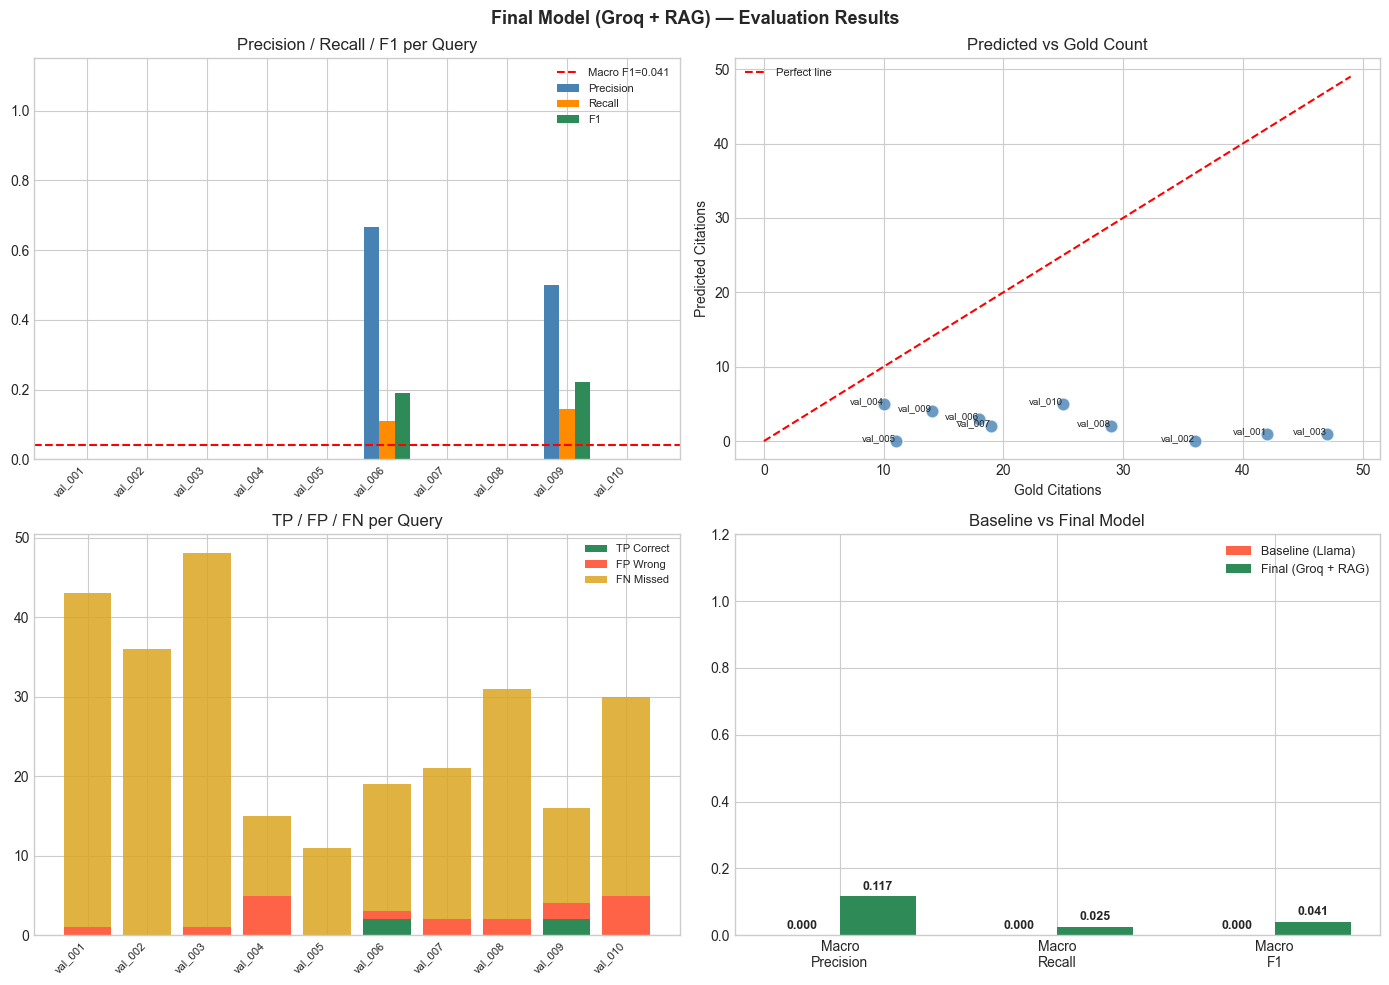

📊 Plot saved!


In [14]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Final Model (Groq + RAG) — Evaluation Results', fontsize=13, fontweight='bold')

# Plot 1: P/R/F1 per query
ax = axes[0, 0]
x  = np.arange(len(metrics_df))
w  = 0.26
ax.bar(x-w, metrics_df['precision'], w, label='Precision', color='steelblue')
ax.bar(x,   metrics_df['recall'],    w, label='Recall',    color='darkorange')
ax.bar(x+w, metrics_df['f1'],        w, label='F1',        color='seagreen')
ax.axhline(macro_f1, color='red', linestyle='--', lw=1.5,
           label=f'Macro F1={macro_f1:.3f}')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['query_id'], rotation=45, ha='right', fontsize=8)
ax.set_ylim(0, 1.15)
ax.set_title('Precision / Recall / F1 per Query')
ax.legend(fontsize=8)

# Plot 2: Predicted vs Gold count
ax = axes[0, 1]
ax.scatter(metrics_df['n_gold'], metrics_df['n_pred'], s=90,
           color='steelblue', alpha=0.8, edgecolors='white')
max_v = max(metrics_df['n_gold'].max(), metrics_df['n_pred'].max()) + 2
ax.plot([0, max_v], [0, max_v], 'r--', lw=1.5, label='Perfect line')
ax.set_xlabel('Gold Citations')
ax.set_ylabel('Predicted Citations')
ax.set_title('Predicted vs Gold Count')
for _, row in metrics_df.iterrows():
    ax.annotate(row['query_id'], (row['n_gold'], row['n_pred']),
                fontsize=7, ha='right')
ax.legend(fontsize=8)

# Plot 3: TP/FP/FN stacked
ax = axes[1, 0]
ax.bar(x, metrics_df['tp'], label='TP Correct',   color='seagreen')
ax.bar(x, metrics_df['fp'], bottom=metrics_df['tp'],
       label='FP Wrong',    color='tomato')
ax.bar(x, metrics_df['fn'],
       bottom=metrics_df['tp']+metrics_df['fp'],
       label='FN Missed',   color='goldenrod', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['query_id'], rotation=45, ha='right', fontsize=8)
ax.set_title('TP / FP / FN per Query')
ax.legend(fontsize=8)

# Plot 4: Baseline vs Final comparison
ax = axes[1, 1]
labels = ['Macro\nPrecision', 'Macro\nRecall', 'Macro\nF1']
baseline_vals = [0.0, 0.0, 0.0]
final_vals    = [macro_p, macro_r, macro_f1]
x2 = np.arange(len(labels))
w2 = 0.35
b1 = ax.bar(x2-w2/2, baseline_vals, w2, label='Baseline (Llama)',  color='tomato')
b2 = ax.bar(x2+w2/2, final_vals,    w2, label='Final (Groq + RAG)', color='seagreen')
for bar in list(b1)+list(b2):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax.set_xticks(x2)
ax.set_xticklabels(labels)
ax.set_ylim(0, 1.2)
ax.set_title('Baseline vs Final Model')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(OUTPUT_PATH / 'final_model_results.png', bbox_inches='tight')
plt.show()
print("📊 Plot saved!")

In [15]:
full = metrics_df.merge(val_df[['query_id','query','gold_citations']], on='query_id')
full = full.merge(val_pred_df[['query_id','predicted_citations']], on='query_id')

print("PER-QUERY ERROR ANALYSIS")
print("=" * 70)

for _, row in full.iterrows():
    pred_set = set(c.strip() for c in str(row['predicted_citations']).split(';') if c.strip())
    gold_set = set(c.strip() for c in row['gold_citations'].split(';') if c.strip())

    correct = sorted(pred_set & gold_set)
    wrong   = sorted(pred_set - gold_set)
    missed  = sorted(gold_set - pred_set)

    emoji = '🟢' if row['f1'] > 0.5 else ('🟡' if row['f1'] > 0.1 else '🔴')
    print(f"\n{emoji} {row['query_id']}  F1={row['f1']:.3f}  Prec={row['precision']:.3f}  Rec={row['recall']:.3f}")
    print(f"   Query  : {str(row['query'])[:100]}...")
    print(f"   ✅ Correct ({len(correct)}) : {', '.join(correct[:5]) or '—'}")
    print(f"   ❌ Wrong   ({len(wrong)}) : {', '.join(wrong[:5]) or '—'}")
    print(f"   ⚠️  Missed  ({len(missed)}) : {', '.join(missed[:5]) or '—'}")

PER-QUERY ERROR ANALYSIS

🔴 val_001  F1=0.000  Prec=0.000  Rec=0.000
   Query  : May a court lawfully order a three‑month extension of pre‑trial detention under Art. 221 Abs. 1 lit....
   ✅ Correct (0) : —
   ❌ Wrong   (1) : Art. 221 Abs. 1 lit. b STPO
   ⚠️  Missed  (42) : 1B_15/2023 E. 3.1, 1B_210/2023 E. 4.1, 1B_28/2022 E. 4.1, 1B_357/2022 E. 3.1, 1B_536/2018 E. 5.1

🔴 val_002  F1=0.000  Prec=0.000  Rec=0.000
   Query  : A claimant holding a national vocational diploma in warehouse operations worked intermittently as a ...
   ✅ Correct (0) : —
   ❌ Wrong   (0) : —
   ⚠️  Missed  (36) : 8C_160/2016 E. 4.1, 8C_421/2023 E. 2.2, 8C_510/2020 E. 2.4, 9C_623/2020 E. 4.2, Art. 1 Abs. 1 IVG

🔴 val_003  F1=0.000  Prec=0.000  Rec=0.000
   Query  : A. Rivera, a Peruvian national born in 1994 and with no prior convictions in the forum state, is acc...
   ✅ Correct (0) : —
   ❌ Wrong   (1) : Art. 221 Abs. 1 STPO
   ⚠️  Missed  (47) : 1B_192/2022 E. 4.1.2, 1B_195/2022 E. 2.2.1, 1B_211/2017 E. 2.1,

In [16]:
print(f"Generating predictions for {len(test_df)} TEST queries...")
print("=" * 60)

test_predictions = []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Test queries"):
    t0   = time.time()
    cits = predict_citations(row['query'])
    elapsed = time.time() - t0

    test_predictions.append({
        'query_id'            : row['query_id'],
        'predicted_citations' : ';'.join(cits) if cits else ' ',
        'n_predicted'         : len(cits),
    })

    print(f"  → {row['query_id']}: {len(cits)} citations in {elapsed:.1f}s")
    time.sleep(0.3)

test_pred_df = pd.DataFrame(test_predictions)
print(f"\n✅ Done! {len(test_pred_df)} test predictions generated")
print(f"   Avg citations per query: {test_pred_df['n_predicted'].mean():.1f}")
print("\nPreview:")
test_pred_df.head()

Generating predictions for 40 TEST queries...


Test queries:   0%|          | 0/40 [00:00<?, ?it/s]

  → test_001: 5 citations in 23.3s
  → test_002: 2 citations in 32.4s
  → test_003: 1 citations in 33.6s
  → test_004: 1 citations in 28.0s
  → test_005: 3 citations in 33.1s
  → test_006: 0 citations in 27.5s
  → test_007: 5 citations in 32.5s
  → test_008: 1 citations in 26.0s
  → test_009: 0 citations in 24.7s
  → test_010: 2 citations in 24.6s
  → test_011: 0 citations in 30.0s
  → test_012: 2 citations in 25.9s
  → test_013: 5 citations in 21.7s
  → test_014: 3 citations in 25.8s
  → test_015: 0 citations in 24.3s
  → test_016: 0 citations in 28.4s
  → test_017: 5 citations in 22.2s
  → test_018: 1 citations in 32.0s
  → test_019: 1 citations in 23.1s
  → test_020: 1 citations in 23.6s
  → test_021: 2 citations in 28.7s
  → test_022: 2 citations in 30.3s
  → test_023: 1 citations in 29.2s
  → test_024: 7 citations in 26.9s
  → test_025: 0 citations in 30.4s
  → test_026: 0 citations in 27.2s
  → test_027: 4 citations in 31.7s
  → test_028: 1 citations in 24.2s
  → test_029: 2 cita

,query_id,predicted_citations,n_predicted
0,test_001,Art. 8 Abs. 1 BV;Art. 9 Abs. 1 UVG;Art. 28 Abs. 1 ZPO;Art. 261 Abs. 1 ZPO;BGE 141 III 294 E. 5.4,5
1,test_002,Art. 83 SVG;Art. 59 Abs. 1 SVG,2
2,test_003,Art. 267a OR,1
3,test_004,Art. 166 Abs. 2 SCHKG,1
4,test_005,Art. 8 Abs. 1 BV;Art. 221 Abs. 1 STPO;BGE 141 II 345,3


In [ ]:
# ── Val submission ────────────────────────────────────────
val_sub_path = OUTPUT_PATH / 'val_submission.csv'
val_pred_df[['query_id','predicted_citations']].to_csv(val_sub_path, index=False)
print(f"✅ Val predictions saved  → {val_sub_path}")

# ── Val metrics ───────────────────────────────────────────
met_path = OUTPUT_PATH / 'val_metrics.csv'
metrics_df.to_csv(met_path, index=False)
print(f"✅ Val metrics saved      → {met_path}")

# ── Test submission (final competition file) ──────────────
test_sub_path = OUTPUT_PATH / 'test_submission.csv'
test_pred_df[['query_id','predicted_citations']].to_csv(test_sub_path, index=False)
print(f"✅ Test submission saved  → {test_sub_path}")

# ── Final scorecard ───────────────────────────────────────
print()
print("╔" + "═"*50 + "╗")
print("║            FINAL MODEL SCORECARD               ║")
print("╠" + "═"*50 + "╣")
print(f"║  Model          : Groq {GROQ_MODEL[:20]:<20}║")
print(f"║  Method         : RAG (BM25 + laws_de.csv)    ║")
print(f"║  Val queries    : {len(val_df):<31}║")
print(f"║  Test queries   : {len(test_df):<31}║")
print("╠" + "═"*50 + "╣")
print(f"║  Baseline F1    : 0.0000                       ║")
print(f"║  Final F1       : {macro_f1:<31.4f}║")
print(f"║  Improvement    : +{macro_f1:.4f}                      ║")
print("╠" + "═"*50 + "╣")
print(f"║  Macro Precision: {macro_p:<31.4f}║")
print(f"║  Macro Recall   : {macro_r:<31.4f}║")
print("╚" + "═"*50 + "╝")
print(f"\n📁 Submit: {test_sub_path}")